<a href="https://colab.research.google.com/github/Aranzazu21/Hands-on-1-2/blob/master/REDES_MULTICAPA_XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Configuración del Entorno y Reproducibilidad

Antes de construir nuestra red neuronal, debemos preparar las herramientas necesarias y asegurar que nuestros experimentos sean consistentes.

### Las Librerías
* **`numpy` (np):** Es la librería estándar para el manejo de matrices y álgebra lineal. En Deep Learning, casi todo se resume a multiplicar matrices de pesos.
* **`matplotlib.pyplot` (plt):** La utilizaremos para visualizar el progreso del entrenamiento mediante una gráfica de pérdida (loss).

### El Concepto de Semilla Aleatoria (`np.random.seed`)
Las redes neuronales comienzan con pesos aleatorios. Sin embargo, en computación, lo "aleatorio" es en realidad una secuencia predefinida.

Al fijar la semilla en **42**, garantizamos la **reproducibilidad**:
1.  Cada vez que ejecutemos, obtendrás los mismos pesos iniciales.
2.  Si usamos código con un compañero, él verá exactamente los mismos resultados que tú.
3.  Evitamos que una "mala suerte" en la inicialización aleatoria nos haga creer que nuestro código está mal.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Configuramos una semilla para que los resultados sean siempre los mismos
np.random.seed(42)

# 2. El Cerebro de la Neurona: Funciones de Activación

Para que nuestra red neuronal sea capaz de aprender patrones complejos (no lineales) como el XOR, necesitamos aplicar una función de activación.

### ¿Qué es la Función Sigmoide?
La función **Sigmoide** toma cualquier número real y lo "aplasta" para que siempre esté en un rango entre **0 y 1**.
* Si el resultado es cercano a 1, la neurona está "activa".
* Si es cercano a 0, la neurona está "inactiva".

Su fórmula matemática es:
$$f(x) = \frac{1}{1 + e^{-x}}$$

### La Importancia de la Derivada
Para el algoritmo de **Backpropagation**, necesitamos saber cómo cambia la salida respecto a la entrada. La derivada de la sigmoide tiene una propiedad matemática muy elegante que nos permite calcularla usando el valor que ya obtuvimos en la propia sigmoide, lo que ahorra mucho cómputo:
$$f'(x) = f(x) \cdot (1 - f(x))$$

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    # 'x' ya es el valor de salida de la sigmoide
    return x * (1 - x)

# 3. Datos de Entrenamiento y Arquitectura de la Red

En esta etapa, definimos qué queremos que la red aprenda y preparamos la estructura física (neuronas y conexiones).

### El Problema XOR
La tabla de verdad de XOR es famosa porque no se puede resolver con una sola línea (no es linealmente separable).
* $0 \oplus 0 = 0$
* $0 \oplus 1 = 1$
* $1 \oplus 0 = 1$
* $1 \oplus 1 = 0$

### Definición de la Arquitectura (2 -> 4 -> 1)
Nuestra red tendrá tres capas:Aunque visualmente vemos 3 niveles (Entrada, Oculta, Salida), técnicamente estamos ante un **Perceptrón Multicapa de 2 capas de procesamiento**.
1.  **Capa de Entrada (2 neuronas):** Representan los dos bits de entrada del XOR.
2.  **Capa Oculta (4 neuronas):** Aquí es donde ocurre la "magia". Cuatro neuronas permiten a la red crear las combinaciones necesarias para entender el patrón XOR.
3.  **Capa de Salida (1 neurona):** Nos da la probabilidad de que el resultado sea 1 o 0.

### Hiperparámetros
* **Learning Rate (`lr`):** Controla qué tan grandes son los pasos que damos al ajustar los pesos. Un valor de 0.2 es un buen equilibrio entre velocidad y estabilidad.
* **Epochs (20,000):** Es la cantidad de veces que la red verá el dataset completo para aprender de él.

In [ ]:
# Datos XOR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Arquitectura 2 -> 4 -> 1
w_hidden = np.random.uniform(size=(2, 4))
b_hidden = np.random.uniform(size=(1, 4))
w_output = np.random.uniform(size=(4, 1))
b_output = np.random.uniform(size=(1, 1))

lr = 0.2
epochs = 20000

# 4. El Ciclo de Entrenamiento (The Training Loop)

Este bloque de código representa el "latido" de la inteligencia artificial. Se repetirá **20,000 veces**, y en cada iteración la red intentará ser un poco mejor que en la anterior.

### Paso A: Forward Pass (Hacia adelante)
Es el camino que siguen los datos desde la entrada hasta la predicción.
1. Multiplicamos las entradas `X` por los pesos ocultos `w_hidden`.
2. Sumamos el sesgo `b_hidden`.
3. Pasamos el resultado por la función `sigmoid` para obtener `hidden_act`.
4. Repetimos el proceso para la capa de salida.

### Paso B: Cálculo del Error
Comparamos lo que la red predijo (`output_act`) con lo que debería haber salido (`y`). Usamos el **Error Cuadrático Medio (MSE)** para guardar el progreso y ver cómo disminuye el error con el tiempo.

### Paso C: Backpropagation (Hacia atrás)
Aquí es donde ocurre el aprendizaje. La red calcula qué tanto "culpable" es cada peso del error cometido.
* Usamos la **derivada de la sigmoide** para saber en qué dirección ajustar los valores.
* El error se propaga desde la salida hacia atrás, llegando hasta la primera capa de pesos.

### Paso D: Actualización de Parámetros
Finalmente, ajustamos los pesos y sesgos usando el **Gradiente Descendiente**:
$$Peso_{nuevo} = Peso_{anterior} + (Entrada^T \cdot Gradiente \cdot lr)$$

In [ ]:
losses = []

for epoch in range(epochs):
    # Forward Pass
    hidden_act = sigmoid(np.dot(X, w_hidden) + b_hidden)
    output_act = sigmoid(np.dot(hidden_act, w_output) + b_output)

    # Cálculo del Error
    error = y - output_act
    losses.append(np.mean(np.square(error)))

    # Backpropagation
    d_output = error * sigmoid_derivative(output_act)
    d_hidden = (d_output.dot(w_output.T)) * sigmoid_derivative(hidden_act)

    # Actualización de parámetros
    w_output += hidden_act.T.dot(d_output) * lr
    b_output += np.sum(d_output, axis=0, keepdims=True) * lr
    w_hidden += X.T.dot(d_hidden) * lr
    b_hidden += np.sum(d_hidden, axis=0, keepdims=True) * lr

print("¡Entrenamiento finalizado!")

¡Entrenamiento finalizado!


# 5. Evaluación de Resultados y Curva de Aprendizaje


### 1. Las Predicciones
Observa los valores finales. Para una compuerta XOR ideal, esperaríamos valores exactos de 0 y 1. Sin embargo, las redes neuronales trabajan con **probabilidades**.
* Si el valor es `0.98...`, la red está muy segura de que la respuesta es **1**.
* Si el valor es `0.01...`, está segura de que es **0**.

### 2. La Curva de Aprendizaje (Loss Curve)
La gráfica que vemos continuación muestra cómo el error (MSE) disminuye a medida que pasan las épocas.
* **Al principio:** El error es alto porque los pesos son aleatorios.
* **La caída:** Representa el momento en que la red "descubre" el patrón del XOR.
* **La meseta:** Indica que la red ya ha aprendido lo máximo posible con esta configuración.

Predicciones finales:
Entrada [0 0] -> Salida [0.0162]
Entrada [0 1] -> Salida [0.9889]
Entrada [1 0] -> Salida [0.9758]
Entrada [1 1] -> Salida [0.0215]


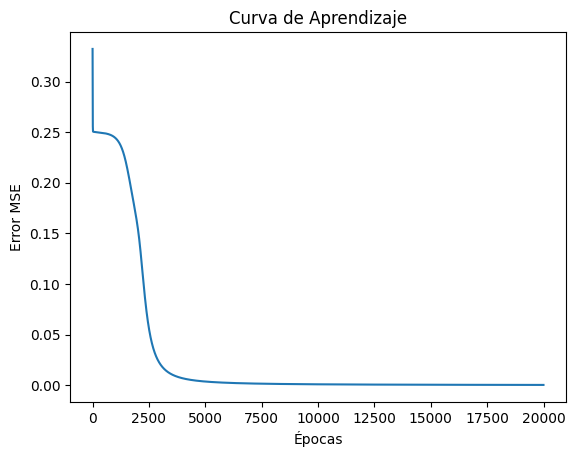

In [ ]:
# Mostrar predicciones
print("Predicciones finales:")
for i in range(len(X)):
    print(f"Entrada {X[i]} -> Salida {output_act[i].round(4)}")

# Graficar pérdida
plt.plot(losses)
plt.title("Curva de Aprendizaje")
plt.xlabel("Épocas")
plt.ylabel("Error MSE")
plt.show()

In [ ]:
# 1. Convertimos las probabilidades de la última capa a 0 o 1
# Usamos output_act que es el resultado del entrenamiento
predictions = [1 if x > 0.5 else 0 for x in output_act]

# 2. Aplanamos 'y' para que sea compatible (de matriz a vector)
y_real = y.flatten()

print("\n--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(y_real, predictions))

print(f"\nExactitud (Accuracy): {accuracy_score(y_real, predictions)*100:.2f}%")

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_real, predictions))


--- MATRIZ DE CONFUSIÓN ---
[[2 0]
 [0 2]]

Exactitud (Accuracy): 100.00%

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

